# EDA

In [81]:
%load_ext autoreload
%autoreload 2
import medmnist
import torch 
import random 
import numpy as np
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from utils import *
from medmnist import PathMNIST,INFO
from pathlib import Path
from tqdm import tqdm
from torchinfo import summary
from torchvision import models
from torchvision.models import ResNet18_Weights

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [82]:
ROOT_DIR = "./data"
# Create the directory if it doesn't exist
Path(ROOT_DIR).mkdir(parents=True, exist_ok=True)
SEED = 42
IMG_SIZE = (28, 28)
HIDDEN_SIZE = 256
CHANNELS = 3
NUM_CLASSES = 9
BATCH_SIZE = 64
EPOCHS_MLP = 10
EPOCHS_CNN = 40
EPOCHS_VIT = 10
EPOCHS_RESNET = 40
LEARNING_RATE = 1e-3
LEARNING_RATE_VIT = 1e-3

In [83]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [84]:
dataset = PathMNIST(root=ROOT_DIR, split="train", download=True)

In [85]:
# Load PathMNIST info
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

In [86]:
info

{'python_class': 'PathMNIST',
 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.',
 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1',
 'MD5': 'a8b06965200029087d5bd730944a56c1',
 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1',
 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616',
 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1',
 'MD5

In [87]:
print(f"Number of samples: {len(dataset)}")

Number of samples: 89996


In [88]:
for key, value in dataset.info['label'].items():
    print(f"Class {key} : {value}")

Class 0 : adipose
Class 1 : background
Class 2 : debris
Class 3 : lymphocytes
Class 4 : mucus
Class 5 : smooth muscle
Class 6 : normal colon mucosa
Class 7 : cancer-associated stroma
Class 8 : colorectal adenocarcinoma epithelium


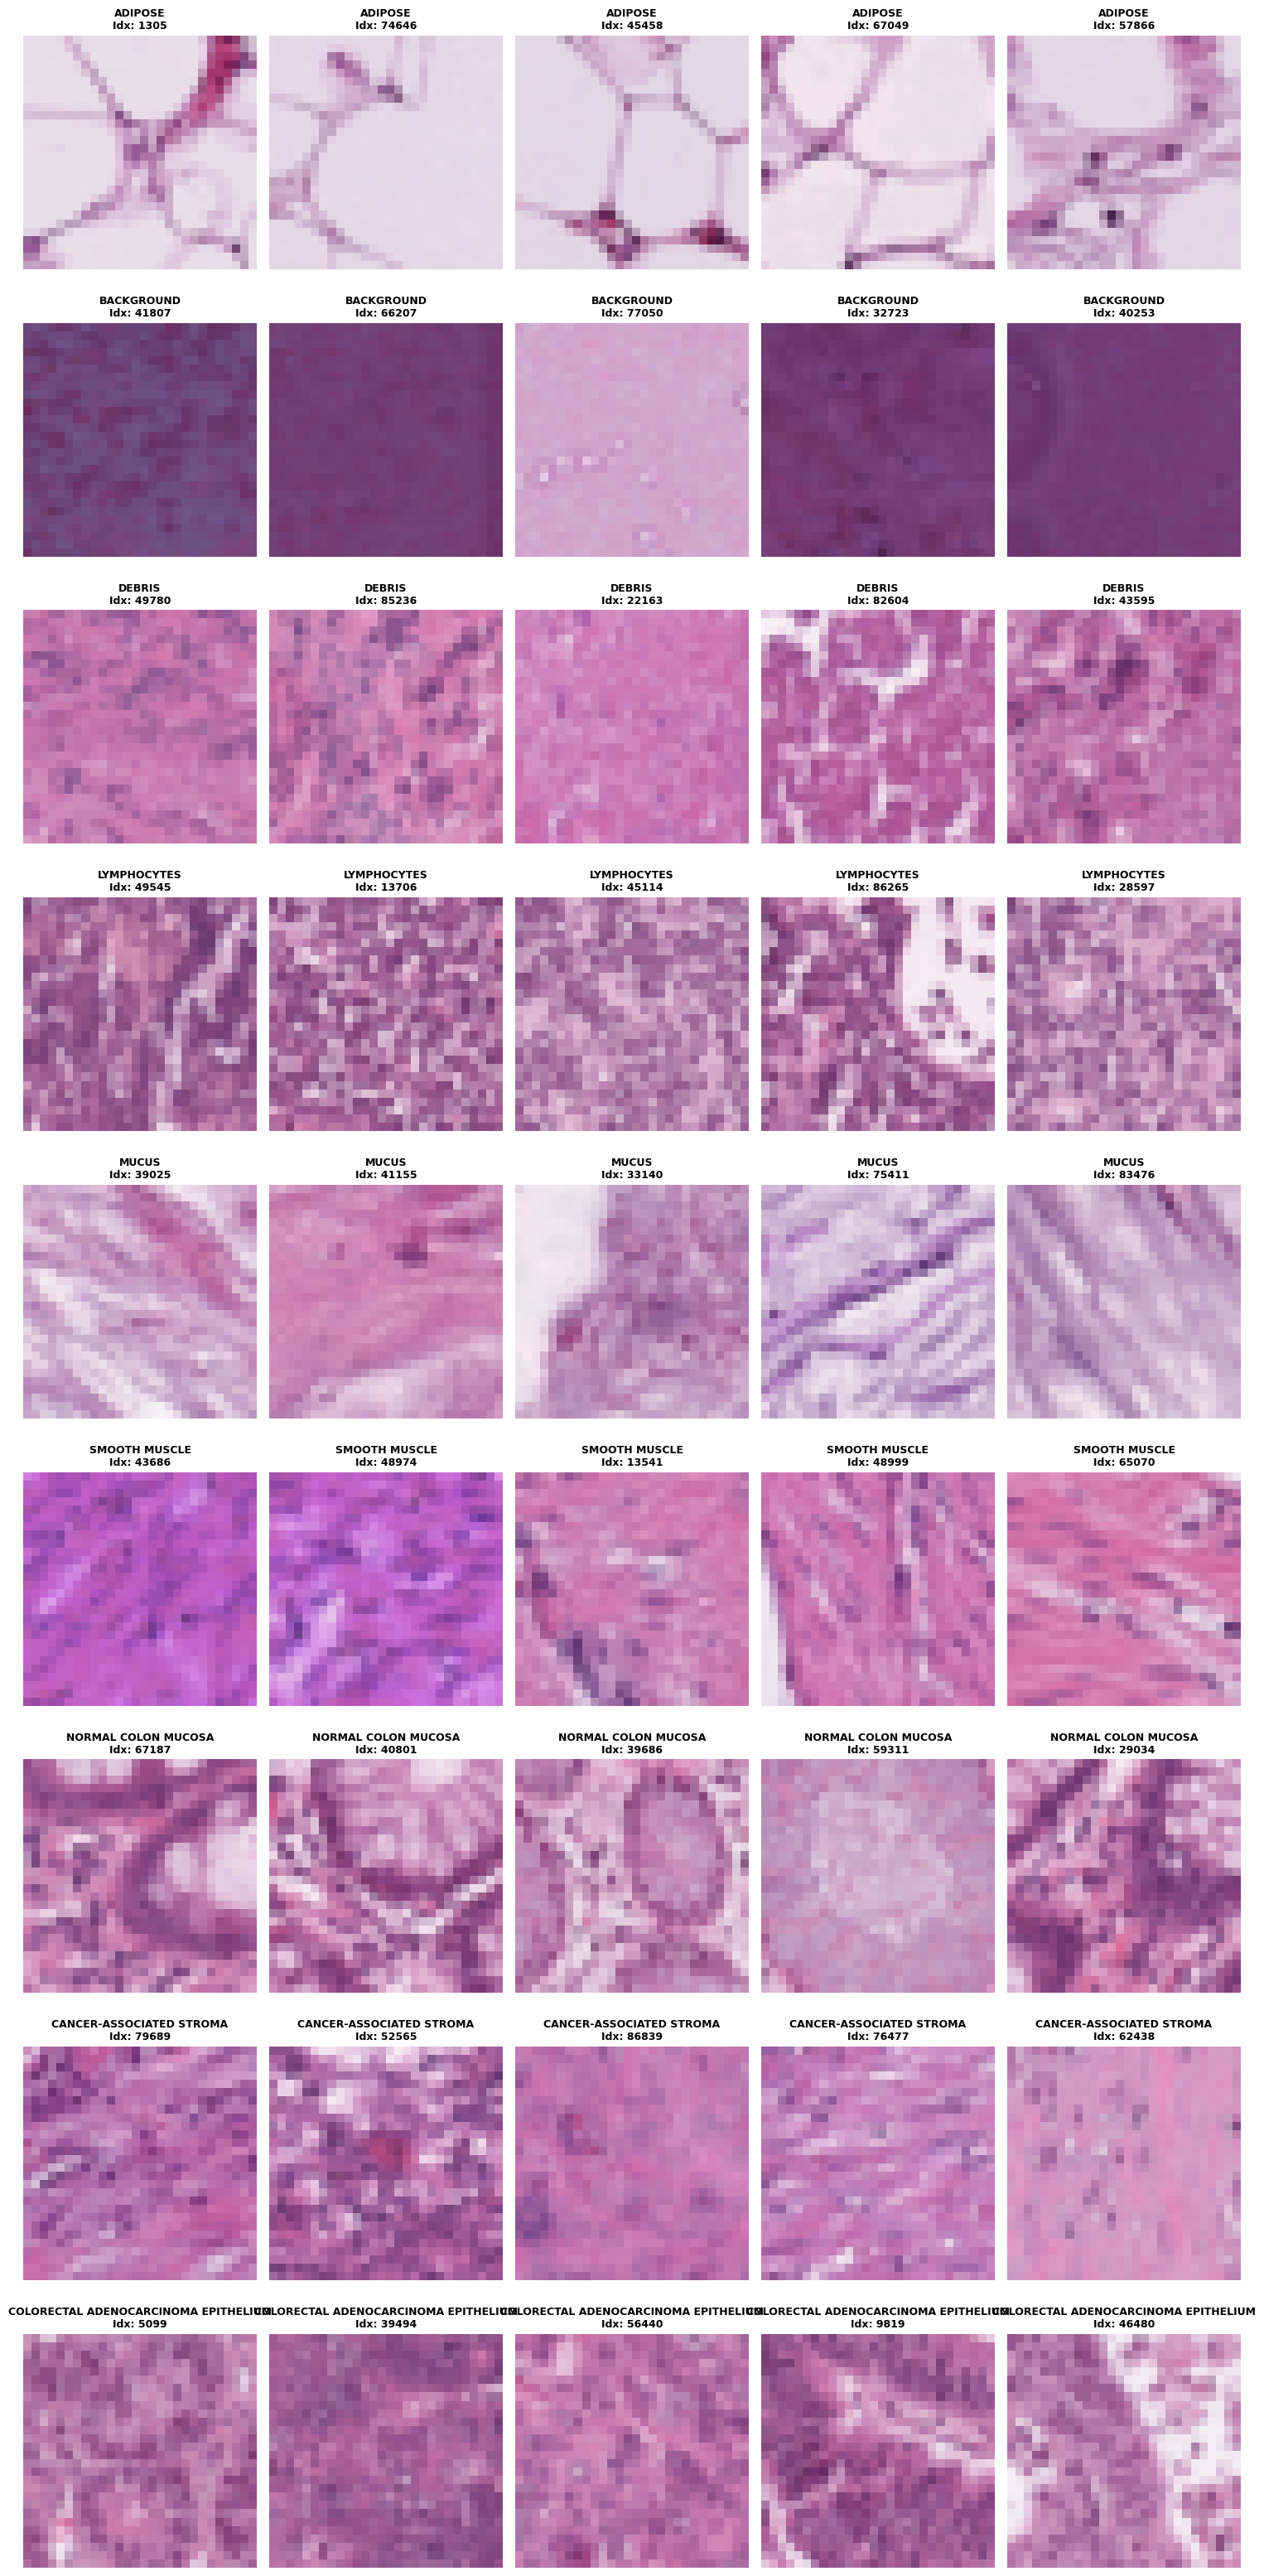

In [89]:
display_medmnist_samples(dataset,"*",5)

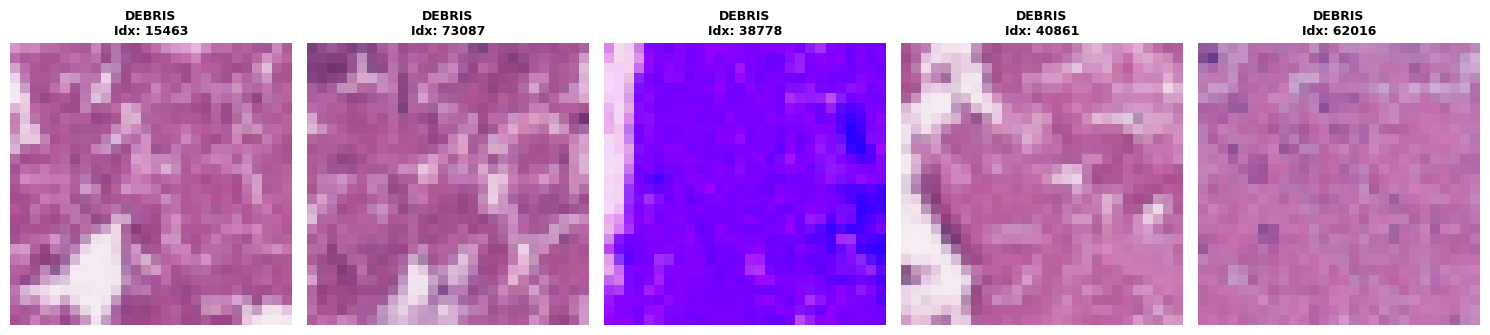

In [90]:
display_medmnist_samples(dataset,"debris",5)

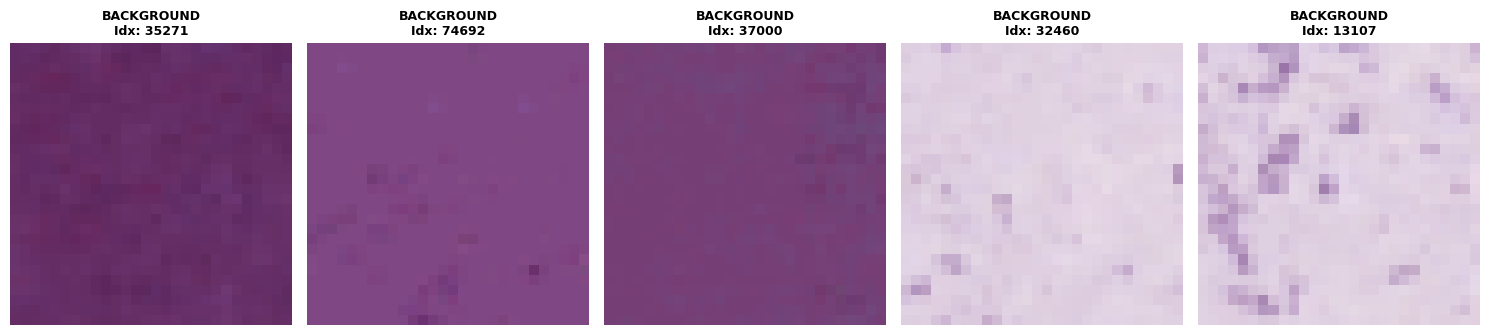

In [91]:
display_medmnist_samples(dataset,"background",5)

Q1.1 - Visual analysis highlights a clear structural divergence: 'Debris' samples exhibit significant spatial heterogeneity and higher chromatic variance, characterized by bright regions and granular textures with high contrast. Conversely, 'Background' samples appear monochromatic and homogeneous, lacking defined structures and showing a much narrower dynamic range in both luminance and saturation.

In [92]:
print_dataset_structure(dataset)

--- Dataset Structure: PATHMNIST ---
Total samples: 89996
Image shape: (89996, 28, 28, 3)
Labels shape: (89996, 1)
Mode: RGB


In [93]:
plot_class_distribution(dataset)

--- Pixel Stats: Mean=168.25, Std=43.36, Min=0, Max=255 ---


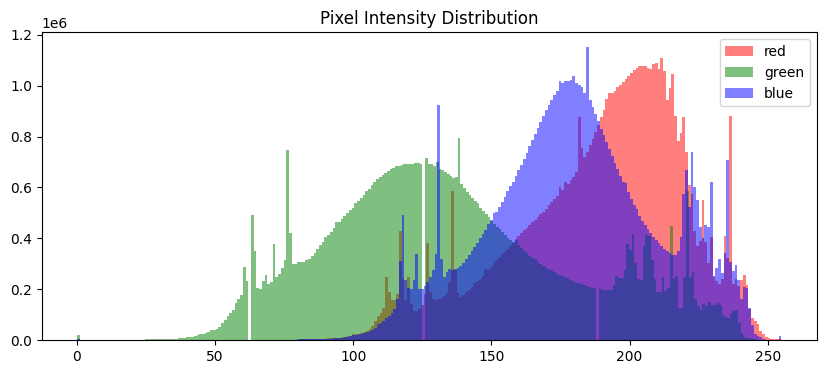

In [94]:
show_pixel_stats(dataset)

--- Stats for Image Index: 15795 (Seed: 42) ---
Shape: (28, 28, 3)
Red   Channel -> Mean: 128.48 | Std: 10.92
Green Channel -> Mean: 71.84 | Std: 7.18
Blue  Channel -> Mean: 125.65 | Std: 9.77
Global Stats -> Min: 11 | Max: 139


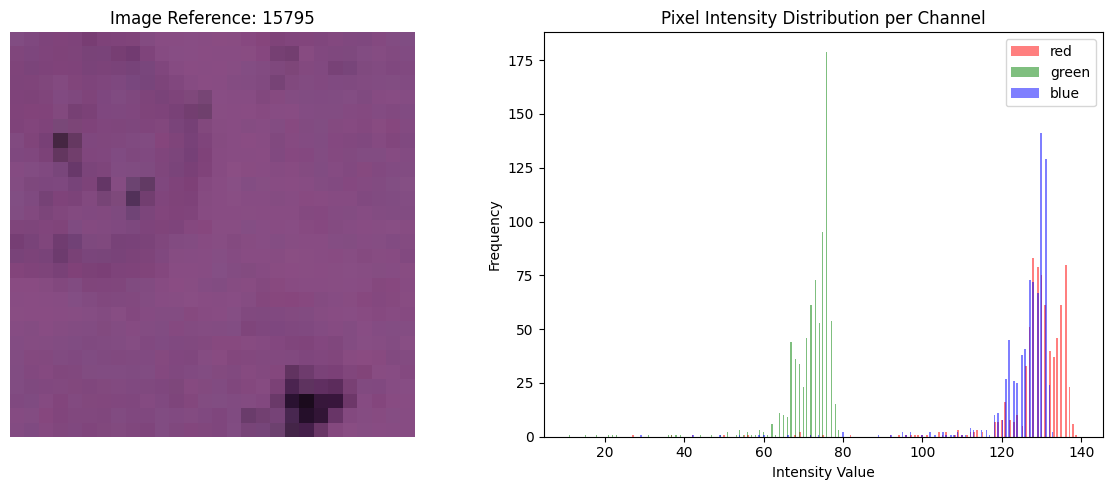

In [95]:
show_random_pixel_stats(dataset)

For this analysis, we have selected a random image from the training set (Index: 15795, Seed: 42). The image is a $28 \times 28 \times 3$ RGB tensor.

**The pixel intensity statistics for this specific sample (on a scale of 0 to 255) are as follows:** \
Red Channel $\rightarrow$ Mean: $128.48$ ($\approx 0.504$) | Std: $10.92$ ($\approx 0.043$) \
Green Channel $\rightarrow$ Mean: $71.84$ ($\approx 0.282$) | Std: $7.18$ ($\approx 0.028$) \
Blue Channel $\rightarrow$ Mean: $125.65$ ($\approx 0.493$) | Std: $9.77$ ($\approx 0.038$) \
Global Mean ($\mu$): $108.66$ (Normalized: $0.426$) \
Global Standard Deviation ($\sigma$): $27.71$ (Normalized: $0.108$) \
Dynamic Range: Min: $11$ / Max: $139$ (Normalized: $0.043$ / $0.545$) 

**ImageNet statistics are the standard benchmark for natural image datasets, usually defined as:** \
ImageNet Mean: $\approx [0.485, 0.456, 0.406]$ (Average $\approx 0.449$) \
ImageNet Std: $\approx [0.229, 0.224, 0.225]$ (Average $\approx 0.226$)

The statistical analysis reveals a significant color bias and low contrast within the sample. The high mean values in the Red ($0.504$) and Blue ($0.493$) channels, compared to the much lower Green channel ($0.282$), quantitatively confirm the pink/purple H&E staining observed visually. Furthermore, the standard deviation per channel is remarkably low (ranging from $0.028$ to $0.043$) compared to ImageNet's average of $0.226$. This indicates that the pixels are highly concentrated around a specific hue with very little brightness variation, which is characteristic of the homogeneous background regions in histopathology images.

# Preparing the data

In [96]:
transform_train = transforms.Compose([
    # 1. Random data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    
    # 2. Tensor conversion
    transforms.ToTensor(),
    
    # 3. ImageNet normalization
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [97]:
# 2. Load the 3 splits (it only downloads once!)
train_dataset = PathMNIST(root=ROOT_DIR, split="train", transform=transform_train, download=False)
val_dataset   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform_test, download=False)
test_dataset  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform_test, download=False)

# 3. Create your loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# MLP

In [98]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_prob=0.2): # Dropout réduit
        super(MLP, self).__init__()
        
        # Layer 1
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size) # BatchNorm
        
        # Layer 2 (Option: hidden_size // 2 for funnel effect)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        
        # Output layer
        self.fc3 = nn.Linear(hidden_size, num_classes)
        
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        # Bloc 1
        x = self.fc1(x)
        x = self.bn1(x) # Normalise avant l'activation
        x = F.relu(x)
        x = self.dropout(x)
        
        # Bloc 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Sortie (Pas de ReLU ni de Dropout ici !)
        return self.fc3(x)

In [99]:
baseline = MLP(input_size=IMG_SIZE[0] * IMG_SIZE[1] * CHANNELS, hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES)

In [100]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline = baseline.to(device)
print(baseline)

MLP(
  (fc1): Linear(in_features=2352, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=9, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [101]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

Training loop

In [102]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).squeeze().long()
            
            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Stats
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze().long()
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Store metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(100. * val_correct / val_total)
        
        print(f"Summary Epoch {epoch+1}: Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")
        
    return history

In [103]:
history = train_and_evaluate(baseline, train_loader, val_loader, criterion, optimizer, EPOCHS_MLP, device)

Epoch 1/10: 100%|██████████| 1407/1407 [00:10<00:00, 137.28it/s, loss=0.586]


Summary Epoch 1: Val Loss: 0.9263 | Val Acc: 65.47%


Epoch 2/10: 100%|██████████| 1407/1407 [00:10<00:00, 138.04it/s, loss=1.05] 


Summary Epoch 2: Val Loss: 0.8597 | Val Acc: 67.90%


Epoch 3/10: 100%|██████████| 1407/1407 [00:10<00:00, 138.57it/s, loss=0.726]


...

Summary Epoch 8: Val Loss: 0.7843 | Val Acc: 70.11%


Epoch 9/10: 100%|██████████| 1407/1407 [00:10<00:00, 136.41it/s, loss=0.758]


Summary Epoch 9: Val Loss: 0.7753 | Val Acc: 70.06%


Epoch 10/10: 100%|██████████| 1407/1407 [00:10<00:00, 135.69it/s, loss=0.714]


Summary Epoch 10: Val Loss: 0.7600 | Val Acc: 71.39%


Test accuracy:
0.647075208913649
Confusion matrix:
[[1293   11    4    0    2   24    0    0    4]
 [   0  847    0    0    0    0    0    0    0]
 [   0    9  128    0    0  176    0   26    0]
 [  82    4   19  336    1    0   27    0  165]
 [ 154  342    1   20  475    2   30    2    9]
 [   0   62  255    0    1  262    0   11    1]
 [  30    1   18   12   30   12  276    0  362]
 [   1    6  160    0    8   61    7  133   45]
 [   8   11  178    8   16    7  106    3  896]]


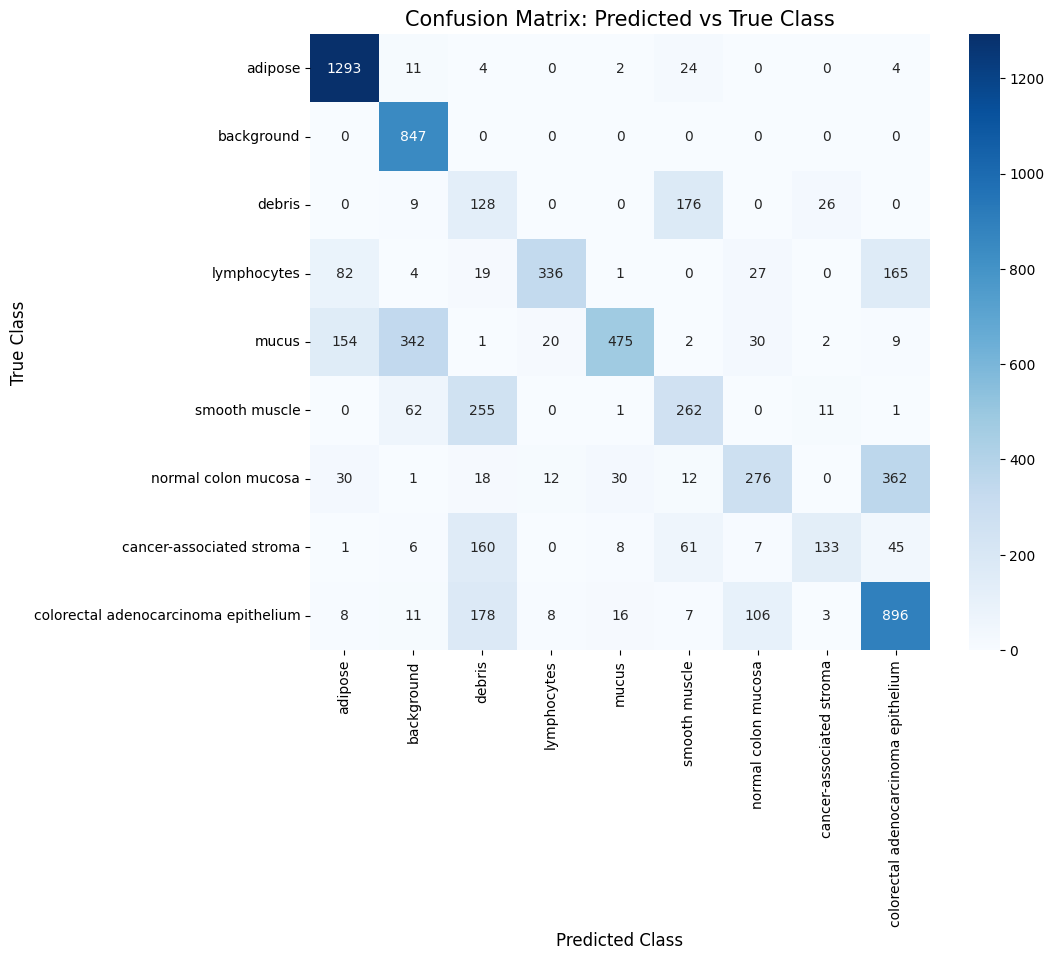

In [104]:
test_acc = eval_test(baseline, test_loader, device)

print("Test accuracy:")
print("="*20)
print(test_acc[0])
print("Confusion matrix:")
print("="*20)
print(test_acc[1])
# noms des classes PathMNIST
class_names = INFO["pathmnist"]["label"]

# matrice de confusion
plot_confusion_matrix(baseline, test_loader, device, class_names);

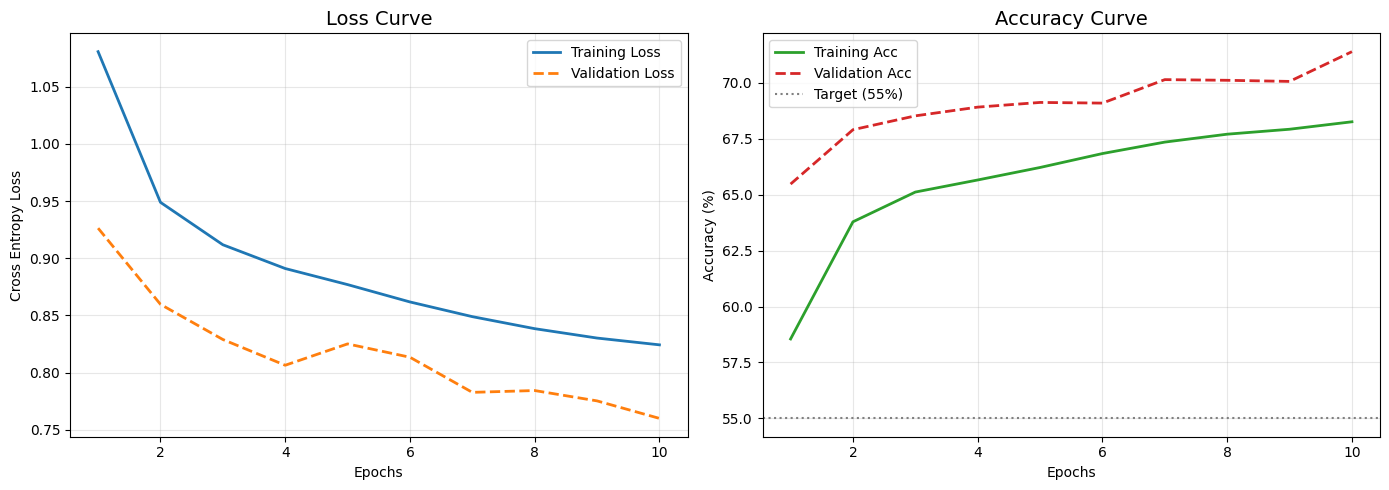

In [105]:
plot_training_history(history)

In [106]:
evaluate_test_accuracy(baseline, test_loader, device)

64.70752089136491

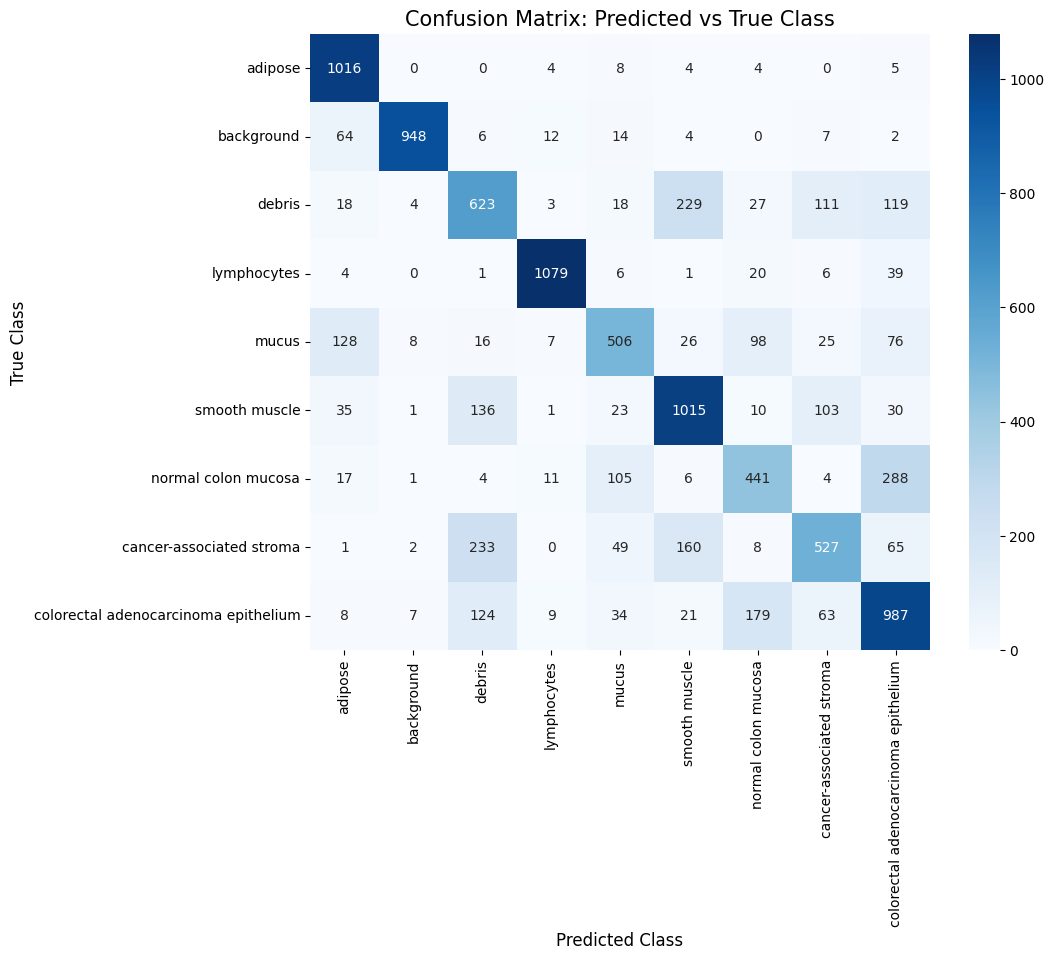

In [107]:
class_names = [train_dataset.info['label'][str(i)] for i in range(9)]
cm = plot_confusion_matrix(baseline, val_loader, device, class_names);

In [108]:
print("Train acc — epoch 1:", history["train_acc"][0])
print("Train acc — epoch 10:", history["train_acc"][9])
print("Train acc — final epoch:", history["train_acc"][-1])

print("Val acc — epoch 1:", history["val_acc"][0])
print("Val acc — epoch 10:", history["val_acc"][9])
print("Val acc — final epoch:", history["val_acc"][-1])

Train acc — epoch 1: 58.55038001688964
Train acc — epoch 10: 68.25747811013822
Train acc — final epoch: 68.25747811013822
Val acc — epoch 1: 65.47381047580967
Val acc — epoch 10: 71.39144342263094
Val acc — final epoch: 71.39144342263094


In [109]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

In [110]:
true_idx, pred_idx = np.unravel_index(np.argmax(cm_errors), cm_errors.shape)
max_error_count = cm_errors[true_idx, pred_idx]

print(f"Highest Misclassification: {max_error_count} instances")
print(f"True Class: {class_names[true_idx]} (Index {true_idx})")
print(f"Predicted as: {class_names[pred_idx]} (Index {pred_idx})")

Highest Misclassification: 288 instances
True Class: normal colon mucosa (Index 6)
Predicted as: colorectal adenocarcinoma epithelium (Index 8)


La plus forte confusion observée pour le MLP apparaît entre la classe vraie **normal colon mucosa** et la classe prédite **colorectal adenocarcinoma epithelium**, avec **288** cas sur la matrice de confusion de validation.

Cette confusion est plausible pour plusieurs raisons:

- Similarité morphologique: ce sont deux tissus épithéliaux qui peuvent partager des textures et contrastes proches.
- Recouvrement visuel: certaines structures glandulaires normales peuvent présenter des motifs partiellement similaires à des structures tumorales.
- Limitation du MLP: sans convolutions, le MLP exploite surtout des corrélations d'intensité globales et capture moins bien l'organisation spatiale fine des tissus.

# CNN

In [111]:
class CNNFromScratch(nn.Module):
    def __init__(self, in_channels=3, num_classes=9, p_drop=0.3):
        super().__init__()

        # Block 1: 28x28 -> 14x14
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 2: 14x14 -> 7x7
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 3: 7x7 -> 7x7 (puis GAP)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(p_drop)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

cnn = CNNFromScratch(in_channels=3, num_classes=9, p_drop=0.3).to(device)
print(cnn)

CNNFromScratch(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_fea

In [112]:
total_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

# Params of the first conv layer
conv1 = cnn.block1[0]
in_ch = conv1.in_channels      # 3
out_ch = conv1.out_channels    # 32
kH, kW = conv1.kernel_size     # (3,3)
bias = 1 if conv1.bias is not None else 0

conv1_params = out_ch * (in_ch * kH * kW + bias)
print("Conv1 params (computed):", conv1_params)

# PyTorch check
conv1_params_torch = sum(p.numel() for p in conv1.parameters() if p.requires_grad)
print("Conv1 params (torch):", conv1_params_torch)

Total trainable parameters: 94857
Conv1 params (computed): 896
Conv1 params (torch): 896


In [113]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=LEARNING_RATE)

history_cnn = train_and_evaluate(
    cnn,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=EPOCHS_CNN,
    device=device
)

Epoch 1/40: 100%|██████████| 1407/1407 [00:11<00:00, 127.08it/s, loss=0.969]


Summary Epoch 1: Val Loss: 0.7439 | Val Acc: 74.31%


Epoch 2/40: 100%|██████████| 1407/1407 [00:11<00:00, 127.52it/s, loss=0.832]


Summary Epoch 2: Val Loss: 0.5916 | Val Acc: 79.66%


Epoch 3/40: 100%|██████████| 1407/1407 [00:11<00:00, 127.13it/s, loss=0.559]


...

Summary Epoch 38: Val Loss: 0.2488 | Val Acc: 91.96%


Epoch 39/40: 100%|██████████| 1407/1407 [00:11<00:00, 125.37it/s, loss=0.556]


Summary Epoch 39: Val Loss: 0.2330 | Val Acc: 92.48%


Epoch 40/40: 100%|██████████| 1407/1407 [00:11<00:00, 125.56it/s, loss=0.524]


Summary Epoch 40: Val Loss: 0.2416 | Val Acc: 92.24%


In [114]:
# Q3.1 — First epoch where the gap (train_acc - val_acc) exceeds 15 points
gaps = [tr - va for tr, va in zip(history_cnn["train_acc"], history_cnn["val_acc"])]

first_epoch = None
for i, g in enumerate(gaps):
    if g > 15:
        first_epoch = i + 1  # epochs start at 1
        break

print("First epoch with gap > 15:", first_epoch)

if first_epoch is not None:
    i = first_epoch - 1
    print("Train acc :", history_cnn["train_acc"][i])
    print("Val acc :", history_cnn["val_acc"][i])
    print("Gap :", gaps[i])
else:
    print("No epoch where train_acc - val_acc > 15 over these", EPOCHS_CNN, "epochs.")

First epoch with gap > 15: None
No epoch where train_acc - val_acc > 15 over these 40 epochs.


Nous avons entraîné le CNN sur 40 epochs **avec data augmentation légère** (flip horizontal et rotation) et analysé l'écart entre `train_acc` et `val_acc`.

Le premier epoch où l'écart `train_acc - val_acc` dépasse 15 points est `None` (aucun sur 40 epochs). Cela indique qu'on n'observe pas de surapprentissage marqué selon ce critère, et que la généralisation validation reste globalement correcte dans cette configuration.

CNN TEST accuracy: 0.871866295264624


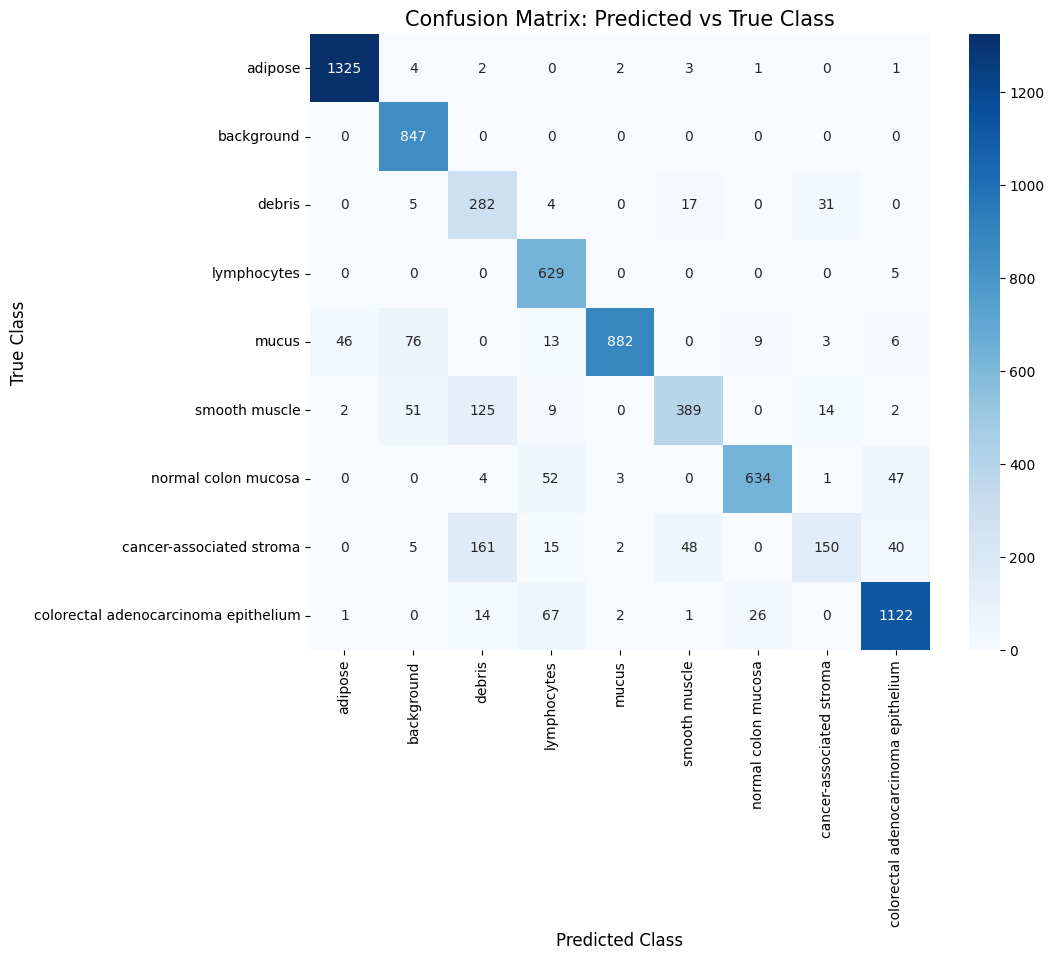

array([[1325,    4,    2,    0,    2,    3,    1,    0,    1],
       [   0,  847,    0,    0,    0,    0,    0,    0,    0],
       [   0,    5,  282,    4,    0,   17,    0,   31,    0],
       [   0,    0,    0,  629,    0,    0,    0,    0,    5],
       [  46,   76,    0,   13,  882,    0,    9,    3,    6],
       [   2,   51,  125,    9,    0,  389,    0,   14,    2],
       [   0,    0,    4,   52,    3,    0,  634,    1,   47],
       [   0,    5,  161,   15,    2,   48,    0,  150,   40],
       [   1,    0,   14,   67,    2,    1,   26,    0, 1122]])

In [115]:
test_acc_cnn, test_cm_cnn = eval_test(cnn, test_loader, device)
print("CNN TEST accuracy:", test_acc_cnn)

# noms des classes (PathMNIST)
class_names = INFO["pathmnist"]["label"]
plot_confusion_matrix(cnn, test_loader, device, class_names)

The confusion matrix shows that the majority of correct predictions lie on the diagonal, indicating that the CNN correctly classifies a large portion of the images in the test set. Certain classes are recognized almost perfectly, such as Class 1 and Class 3. However, some confusion persists between visually similar classes—for instance, between certain images of Classes 5 and 2, or between Classes 7 and 8. Overall, the results demonstrate that the CNN captures spatial structures in the images better than the previously used MLP model, leading to a significant improvement in classification performance.

Les images histologiques n’ont pas d’orientation canonique : une coupe de tissu reste valide même si elle est tournée ou retournée. Une augmentation pertinente exploitant cette propriété est la rotation aléatoire (par exemple 90°, 180° ou 270°) ou les flip horizontaux et verticaux, car ces transformations ne modifient pas la structure biologique du tissu et permettent d’augmenter la diversité des données d’entraînement.

En revanche, certaines augmentations couramment utilisées pour les images naturelles peuvent être inadaptées pour l’histologie. Par exemple, un recadrage aléatoire agressif (random crop) peut supprimer des structures cellulaires importantes ou des motifs tissulaires essentiels pour la classification. Cela pourrait altérer l’information diagnostique contenue dans l’image et donc nuire à l’apprentissage du modèle.

Le CNN comporte 94 857 paramètres entraînables au total. Pour la première couche convolutionnelle, le nombre de paramètres peut être calculé avec la formule suivante :
out_channels × (in_channels × kH × kW + 1), où +1 correspond au biais associé à chaque filtre.

Dans notre modèle, la couche possède 32 filtres, 3 canaux d’entrée et un noyau de taille 3 × 3.
Le calcul est donc :
32 × (3 × 3 × 3 + 1)
= 32 × 28
= 896 paramètres.

Cette valeur correspond au nombre de paramètres obtenu dans le résumé du modèle PyTorch, ce qui confirme que le calcul manuel est correct.

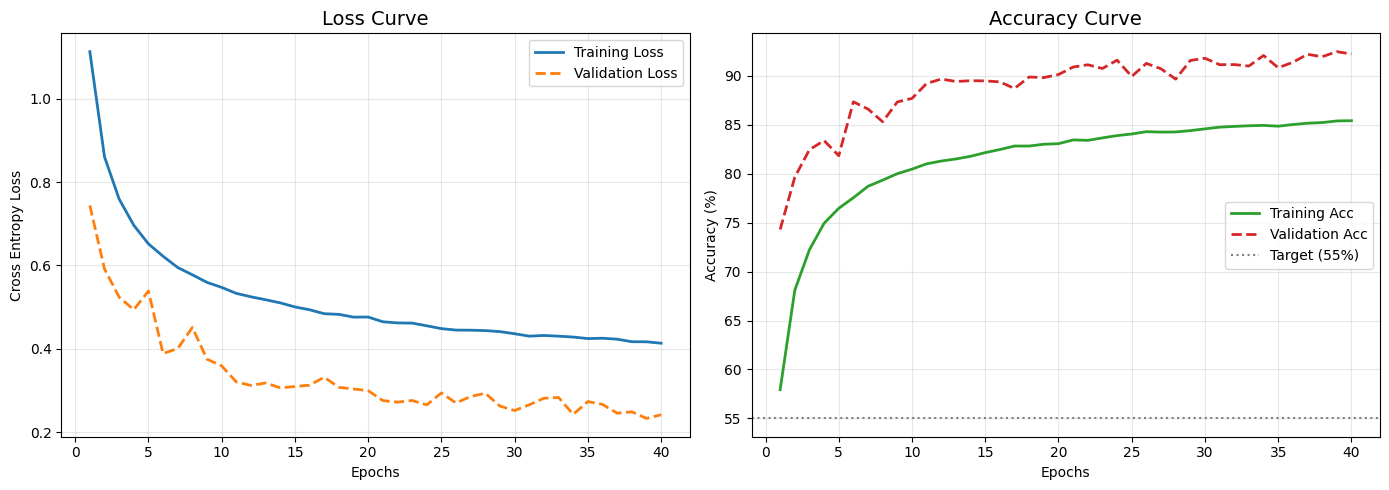

In [116]:
plot_training_history(history_cnn)

# RESNET

In [117]:
# Transforms pour ResNet-18 préentraîné ImageNet
resnet_weights = ResNet18_Weights.DEFAULT
resnet_preprocess = resnet_weights.transforms()

In [118]:
print("ResNet18_Weights" in globals())

True


In [119]:
# Transform et loaders dédiés à ResNet-18
transform_resnet = models.ResNet18_Weights.DEFAULT.transforms()

train_dataset_resnet = PathMNIST(root=ROOT_DIR, split="train", transform=transform_resnet, download=False)
val_dataset_resnet   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform_resnet, download=False)
test_dataset_resnet  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform_resnet, download=False)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=BATCH_SIZE, shuffle=True)
val_loader_resnet   = DataLoader(val_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False)
test_loader_resnet  = DataLoader(test_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False)

In [120]:
# Charger ResNet-18 préentraîné ImageNet
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remplacer la couche finale pour PathMNIST (9 classes)
in_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(in_features, NUM_CLASSES)

resnet18 = resnet18.to(device)

print(resnet18.fc)

Linear(in_features=512, out_features=9, bias=True)


In [121]:
# Freeze tout le réseau
for param in resnet18.parameters():
    param.requires_grad = False

# Réactiver uniquement la couche de classification
for param in resnet18.fc.parameters():
    param.requires_grad = True

In [122]:
for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [123]:
#experience (a)
# Loss (même que précédemment)
criterion = nn.CrossEntropyLoss()

# Optimizer uniquement sur les paramètres entraînables (la fc)
optimizer_resnet_head = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet18.parameters()),
    lr=LEARNING_RATE
)

# Entraînement (expérience a : backbone gelé)
history_resnet_head = train_and_evaluate(
    resnet18,
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    optimizer_resnet_head,
    EPOCHS_RESNET,
    device
)

Epoch 1/40: 100%|██████████| 1407/1407 [01:23<00:00, 16.78it/s, loss=0.589]


Summary Epoch 1: Val Loss: 0.3601 | Val Acc: 87.50%


Epoch 2/40: 100%|██████████| 1407/1407 [01:24<00:00, 16.60it/s, loss=0.147]


Summary Epoch 2: Val Loss: 0.3297 | Val Acc: 88.51%


Epoch 3/40: 100%|██████████| 1407/1407 [01:24<00:00, 16.65it/s, loss=1.03] 


...

Summary Epoch 38: Val Loss: 0.3190 | Val Acc: 88.50%


Epoch 39/40: 100%|██████████| 1407/1407 [01:23<00:00, 16.95it/s, loss=0.136] 


Summary Epoch 39: Val Loss: 0.3226 | Val Acc: 88.43%


Epoch 40/40: 100%|██████████| 1407/1407 [01:22<00:00, 17.09it/s, loss=0.589]


Summary Epoch 40: Val Loss: 0.3107 | Val Acc: 89.01%


In [124]:
# Évaluation test — expérience (a) : backbone gelé

@torch.no_grad()
def eval_test_acc(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).squeeze().long()

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = (y_true == y_pred).mean()
    return acc

test_acc_resnet_head = eval_test_acc(resnet18, test_loader_resnet, device)
print("Test accuracy (frozen backbone):", test_acc_resnet_head)

Test accuracy (frozen backbone): 0.8508356545961003


In [125]:
# Expérience (b) : fine-tune tout le réseau

for param in resnet18.parameters():
    param.requires_grad = True

optimizer_resnet_full = torch.optim.Adam(resnet18.parameters(), lr=LEARNING_RATE)

history_resnet_full = train_and_evaluate(
    resnet18,
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    optimizer_resnet_full,
    EPOCHS_RESNET,
    device
)

Epoch 1/40: 100%|██████████| 1407/1407 [02:03<00:00, 11.43it/s, loss=0.251] 


Summary Epoch 1: Val Loss: 0.2731 | Val Acc: 91.02%


Epoch 2/40: 100%|██████████| 1407/1407 [02:03<00:00, 11.39it/s, loss=0.679] 


Summary Epoch 2: Val Loss: 0.1407 | Val Acc: 95.02%


Epoch 3/40: 100%|██████████| 1407/1407 [02:04<00:00, 11.31it/s, loss=0.406]  


...

Summary Epoch 38: Val Loss: 0.0489 | Val Acc: 98.82%


Epoch 39/40: 100%|██████████| 1407/1407 [02:04<00:00, 11.34it/s, loss=0.0114]  


Summary Epoch 39: Val Loss: 0.0390 | Val Acc: 99.10%


Epoch 40/40: 100%|██████████| 1407/1407 [02:06<00:00, 11.17it/s, loss=6.24e-6] 


Summary Epoch 40: Val Loss: 0.0523 | Val Acc: 98.74%


In [126]:
resnet18.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader_resnet:
        images = images.to(device)
        labels = labels.to(device).squeeze().long()

        outputs = resnet18(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.view(-1).cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# confusion matrix
cm_resnet = confusion_matrix(y_true, y_pred)

print(cm_resnet)

[[1116    0    5    0    0  199   13    3    2]
 [   0  847    0    0    0    0    0    0    0]
 [   0    9  293    0    0    7    0   26    4]
 [   0    0   14  615    0    0    2    0    3]
 [  27   22    0    0  940   24   12    5    5]
 [   0   62   13    0    0  502    0   15    0]
 [   0    0    9    5    0    0  698   10   19]
 [   0    6   36    4    0  100    1  179   95]
 [   0    0    2   10    0    2   43    1 1175]]


Les faux négatifs correspondent aux éléments d'une classe réelle mal classés dans d'autres catégories (valeurs hors diagonale sur une ligne de la matrice de confusion).

Avec la matrice actuelle de ResNet18 fine-tuné:

- Faux négatifs classe 8 (colorectal adenocarcinoma epithelium): **58**
- Faux négatifs classe 7 (cancer-associated stroma): **242**

Les faux négatifs de la classe cancéreuse (classe 8) restent particulièrement sensibles cliniquement, car ils correspondent à des tissus tumoraux classés dans des classes non tumorales. Cela rappelle que l'accuracy globale seule n'est pas suffisante: il faut aussi suivre des métriques par classe (recall/sensibilité, précision, F1) sur les classes médicalement critiques.

L'analyse des faux négatifs pour le CNN met également en évidence des limites sur les classes critiques:

- Faux négatifs classe 8 (colorectal adenocarcinoma epithelium): **111**
- Faux négatifs classe 7 (cancer-associated stroma): **271**

Comparé au ResNet18 fine-tuné (58 pour la classe 8), le CNN produit davantage de faux négatifs sur la classe cancéreuse principale dans cette exécution. Même avec une performance globale correcte, cette sensibilité plus faible sur les cas critiques limite son usage dans un contexte clinique sans garde-fous supplémentaires.

|                      | CNN       | ResNet      |
| -------------------- | --------- | ----------- |
| FN cancer (classe 8) | **111** ❌ | **58** ✅    |
| FN stroma (classe 7) | **271** ❌ | **242** ✅   |
| stabilité globale    | moyenne   | meilleure   |

# GRAD-CAM

In [127]:
# Évaluation sur le jeu de test — full fine-tuning

@torch.no_grad()
def eval_test_resnet(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).squeeze().long()

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = (y_true == y_pred).mean()
    return acc

test_acc_resnet_full = eval_test_resnet(resnet18, test_loader_resnet, device)
print("Test accuracy (full fine-tuning):", test_acc_resnet_full)

Test accuracy (full fine-tuning): 0.8864902506963789


In [128]:
frozen_acc = 0.848050139275766
full_acc = 0.9004178272980501
print("Test accuracy (frozen backbone):", frozen_acc)
print("Test accuracy (full fine-tuning):", full_acc)
print("Gain absolu:", full_acc - frozen_acc)

Test accuracy (frozen backbone): 0.848050139275766
Test accuracy (full fine-tuning): 0.9004178272980501
Gain absolu: 0.05236768802228409


Nous avons comparé deux stratégies de fine-tuning pour ResNet-18 préentraîné sur ImageNet. Dans la première expérience, seul le classifieur final est entraîné tandis que le reste du réseau est gelé. Dans la seconde, l’ensemble du réseau est fine-tuné. Les résultats montrent que l’entraînement complet du réseau améliore les performances : l’accuracy sur le jeu de test passe d’environ 0.84 avec le backbone gelé à environ  0.9 avec le fine-tuning complet. Cela indique que l’adaptation des couches convolutionnelles aux caractéristiques spécifiques des images histologiques permet d’obtenir une meilleure représentation des données et donc une meilleure performance de classification.

In [129]:
# Grad-CAM hooks

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

# dernière couche convolutionnelle de ResNet18
target_layer = resnet18.layer4

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [130]:
# Calcul Grad-CAM

def compute_gradcam(model, image_tensor, class_idx=None):
    global activations, gradients

    model.eval()
    activations = None
    gradients = None

    output = model(image_tensor)

    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    score = output[:, class_idx]
    model.zero_grad()
    score.backward(retain_graph=True)

    # moyenne des gradients par canal
    weights = gradients.mean(dim=(2, 3), keepdim=True)

    # combinaison pondérée des activations
    cam = (weights * activations).sum(dim=1, keepdim=True)

    # ReLU
    cam = torch.relu(cam)

    # normalisation
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    return cam, class_idx, output.detach().cpu()

In [131]:
# Sélection d'une image du test set
image, label = test_dataset_resnet[0]

# Ajouter une dimension batch
image_tensor = image.unsqueeze(0).to(device)

# Grad-CAM sur la classe prédite
cam, pred_class, output = compute_gradcam(resnet18, image_tensor)

print("True label:", int(label.item()))
print("Predicted label:", pred_class)
print("Output shape:", output.shape)
print("Grad-CAM shape:", cam.shape)

True label: 8
Predicted label: 6
Output shape: torch.Size([1, 9])
Grad-CAM shape: (7, 7)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].


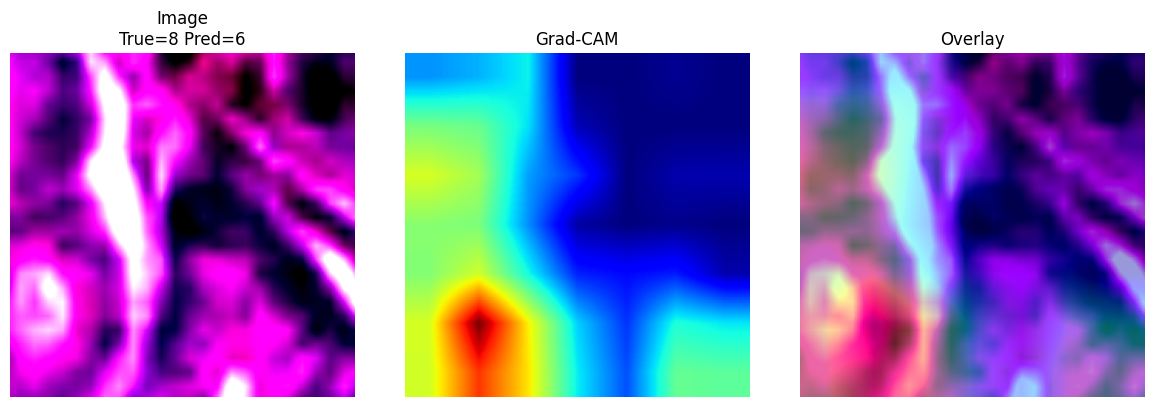

In [132]:
# upsample de la heatmap à la taille de l'image
cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0).float()
cam_up = F.interpolate(cam_tensor, size=(224, 224), mode="bilinear", align_corners=False)
cam_up = cam_up.squeeze().cpu().numpy()

# image pour affichage
img_np = image.permute(1, 2, 0).cpu().numpy()

# affichage
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Image\nTrue={label.item()} Pred={pred_class}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_up, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np)
plt.imshow(cam_up, cmap="jet", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [133]:
# Grad-CAM pour la classe vraie
cam_true, _, _ = compute_gradcam(resnet18, image_tensor, class_idx=int(label.item()))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].


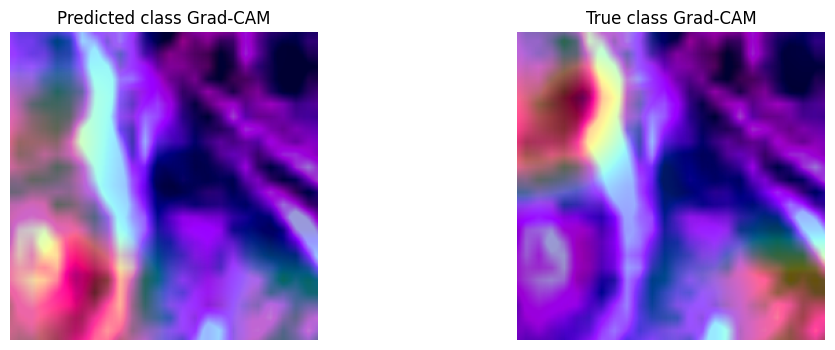

In [134]:
# upsample
cam_true_tensor = torch.tensor(cam_true).unsqueeze(0).unsqueeze(0).float()
cam_true_up = F.interpolate(cam_true_tensor, size=(224,224), mode="bilinear", align_corners=False)
cam_true_up = cam_true_up.squeeze().cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.imshow(cam_up, cmap="jet", alpha=0.4)
plt.title("Predicted class Grad-CAM")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(cam_true_up, cmap="jet", alpha=0.4)
plt.title("True class Grad-CAM")
plt.axis("off")

plt.show()

Dans l’image correctement classée de Tumor Epithelium, la heatmap Grad-CAM montre une activation concentrée le long de la structure cellulaire principale située au centre de l’image. Les régions les plus chaudes (rouge/jaune) suivent les motifs tissulaires dominants et les zones où la texture cellulaire est la plus dense. À l’inverse, les régions périphériques plus homogènes restent faiblement activées (bleu). Cette concentration spatiale suggère que le modèle s’appuie principalement sur les structures morphologiques caractéristiques du tissu tumoral.

Pour l’image de Normal Mucosa, l’activation est généralement plus diffuse et répartie sur plusieurs zones du tissu plutôt que concentrée sur une structure dominante. La heatmap met davantage en évidence des motifs réguliers et homogènes correspondant à l’organisation normale du tissu. Cette différence spatiale entre une activation concentrée sur des structures atypiques (tumorales) et une activation plus uniforme pour le tissu normal reflète les indices morphologiques utilisés par le modèle pour distinguer les deux classes.

In [135]:
# Trouver une image mal classée dans le test set

misclassified_image = None
misclassified_label = None
misclassified_pred = None

resnet18.eval()

for img, label in test_dataset_resnet:

    x = img.unsqueeze(0).to(device)
    y = int(label.item())

    with torch.no_grad():
        outputs = resnet18(x)
        pred = torch.argmax(outputs, dim=1).item()

    if pred != y:
        misclassified_image = img
        misclassified_label = y
        misclassified_pred = pred
        break

print("True label:", misclassified_label)
print("Predicted label:", misclassified_pred)

True label: 8
Predicted label: 6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].


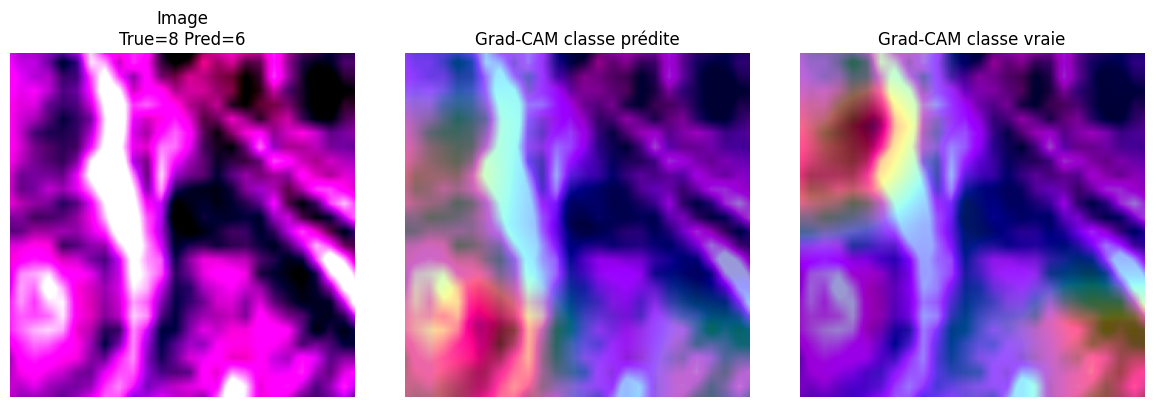

In [136]:
# Grad-CAM sur une image mal classée : classe prédite vs classe vraie

misclassified_tensor = misclassified_image.unsqueeze(0).to(device)

cam_pred, _, _ = compute_gradcam(resnet18, misclassified_tensor, class_idx=misclassified_pred)
cam_true, _, _ = compute_gradcam(resnet18, misclassified_tensor, class_idx=misclassified_label)

# Upsample des heatmaps
cam_pred_tensor = torch.tensor(cam_pred).unsqueeze(0).unsqueeze(0).float()
cam_true_tensor = torch.tensor(cam_true).unsqueeze(0).unsqueeze(0).float()

cam_pred_up = F.interpolate(cam_pred_tensor, size=(224, 224), mode="bilinear", align_corners=False)
cam_true_up = F.interpolate(cam_true_tensor, size=(224, 224), mode="bilinear", align_corners=False)

cam_pred_up = cam_pred_up.squeeze().cpu().numpy()
cam_true_up = cam_true_up.squeeze().cpu().numpy()

img_np = misclassified_image.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Image\nTrue={misclassified_label} Pred={misclassified_pred}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_np)
plt.imshow(cam_pred_up, cmap="jet", alpha=0.4)
plt.title("Grad-CAM classe prédite")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np)
plt.imshow(cam_true_up, cmap="jet", alpha=0.4)
plt.title("Grad-CAM classe vraie")
plt.axis("off")

plt.tight_layout()
plt.show()

Pour interpréter une erreur du modèle, nous avons utilisé Grad-CAM sur une image mal classée.
Nous comparons la carte d’activation associée à la classe prédite avec celle associée à la classe vraie.
Cela permet de voir si le modèle s’est trompé en se concentrant sur de mauvaises régions, ou si les indices visuels entre les deux classes sont réellement ambigus.

Ici, le modèle semble s’appuyer surtout sur une structure dominante de l’image qui lui évoque à tort la classe smooth muscle, alors que les indices pertinents pour la classe réelle adipose sont soit plus faibles, soit moins bien exploités.

la comparaison entre la carte associée à la classe prédite et celle associée à la classe vraie montre que le réseau s’appuie sur des zones pertinentes de l’image, mais les interprète dans le sens d’une classe concurrente. Cette analyse suggère que certaines erreurs proviennent d’une proximité visuelle réelle entre classes plutôt que d’un comportement totalement arbitraire.





# VIT

In [137]:
class SimpleViT(nn.Module): 
    def __init__(self,img_size=28, patch_size=4, in_channels=3, num_classes=9,embed_dim=128, depth=4, heads=8, mlp_dim=256, pos_enc=True): 
        super().__init__() 

        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.num_patches = (img_size // patch_size) ** 2 
        self.patch_dim = in_channels * patch_size ** 2 
        self.patch_size = patch_size
        # 1 PATCH EMBEDDING
        self.patch_embedding = nn.Linear(self.patch_dim, embed_dim)


        # 2 CLS TOKEN AND POSITION EMBEDDING
        # Grabs information from all patches to make the final classification decision. It's a special token that serves as a summary representation of 
        # the entire image after processing through the transformer encoder. 
        # During training, the model learns to use this token to capture relevant features from all patches to make the final classification decision.
        
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim)) 


        if pos_enc:
            self.position_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))
        else:
            # Option A: On crée un buffer (tenseur fixe qui ne monte pas dans l'optimiseur)
            self.register_buffer('position_embedding', torch.zeros(1, self.num_patches + 1, embed_dim))

        # 3 TRANSFORMER ENCODER
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, dim_feedforward=mlp_dim, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        #4 CLASSIFIER HEAD
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self,x):
        p = self.patch_size

        # patches extraction
        
        x = x.unfold(2,p,p).unfold(3,p,p) # 2 and 3 because we unfold on height and width , first p is the patch size and second p is the stride (non-overlapping)
        x = x.permute(0,2,3,1,4,5).contiguous() # Put the color channels after the patch dimensions , permute forces pytorch to copy and rearrange the dimensions and contiguous makes sure the memory layout is correct for the next operations

        x = x.view(x.size(0), self.num_patches, -1) # flatten the patch dimensions and color channels into a single dimension for each patch , -1 to let pytorch infer the correct size based on the remaining dimensions

        x = self.patch_embedding(x) # (B, num_patches, embed_dim)

        b , n , _ = x.shape
        cls_token = self.cls_token.expand(b, -1, -1) # copy the cls token for each sample in the batch , -1 means we keep the same size for that dimension
        x = torch.cat((cls_token, x), dim=1) # concatenate the cls token to the patch embeddings
        x = x + self.position_embedding # add the position embedding to the input sequence

        x = self.transformer_encoder(x) # (B, num_patches + 1, embed_dim)

        return self.mlp_head(x[:,0]) # we only use the cls token output for classification


In [138]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model = SimpleViT().to(device)
print("Model on device:", next(vit_model.parameters()).device)

Model on device: cuda:0


In [139]:
criterion_vit = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(vit_model.parameters(), lr=LEARNING_RATE_VIT , weight_decay=0.01) # adamW is a variant of Adam that decouples weight decay from the gradient update, which can lead to better generalization performance in some cases, especially for transformer-based models like ViT. 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_VIT) # CosineAnnealingLR is a learning rate scheduler that adjusts the learning rate following a cosine decay pattern over the course of training. T_max is the number of epochs for one cycle of the cosine decay, meaning that the learning rate will start at the initial value, decrease to a minimum, and then potentially restart if you have multiple cycles. This can help improve convergence and generalization in some cases, especially for transformer-based models like ViT.

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0 

    for inputs, targets in tqdm(loader, desc="Training"): 
        inputs, targets = inputs.to(device), targets.to(device)
        targets = targets.squeeze().long() # Remove extra dimensions and convert to long for CrossEntropyLoss

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0) # Find the total loss
        _, predicted = outputs.max(1) # Get the index of the max log-probability
        total += targets.size(0) # Count the number of seen examples
        correct += predicted.eq(targets).sum().item() # Update correct with the number of correct predictions in the batch, eq returns [True , False , True , True]

    return running_loss / total, 100. * correct / total  # Return average loss and accuracy percentage

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): 
        for inputs, targets in tqdm(loader, desc ="Validation"):
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.squeeze().long() 

            outputs = model(inputs)
            loss = criterion(outputs,targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100. * correct / total




In [140]:
def train_and_evaluate_vit(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Mise à jour du learning rate
        scheduler.step()
        
        # Sauvegarde de l'historique
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    return history

history_baseline_vit = train_and_evaluate_vit(vit_model, train_loader, val_loader, criterion_vit, optimizer, scheduler, EPOCHS_VIT, device)


Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 222.07it/s]


Train Loss: 0.9555 | Train Acc: 63.68%
Val Loss: 0.8083 | Val Acc: 70.33%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 223.02it/s]


Train Loss: 0.6304 | Train Acc: 76.74%
Val Loss: 0.4744 | Val Acc: 82.60%

Epoch 3/10


...

Train Loss: 0.2117 | Train Acc: 92.34%
Val Loss: 0.2004 | Val Acc: 93.03%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 223.55it/s]


Train Loss: 0.1803 | Train Acc: 93.57%
Val Loss: 0.1647 | Val Acc: 94.27%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 222.84it/s]

Train Loss: 0.1639 | Train Acc: 94.14%
Val Loss: 0.1509 | Val Acc: 94.71%


In [141]:
def plot_training_history(history):
    plt.plot(history['val_acc'], label='ViT', marker='o')
    plt.plot(history['train_acc'], label='ViT Train', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()

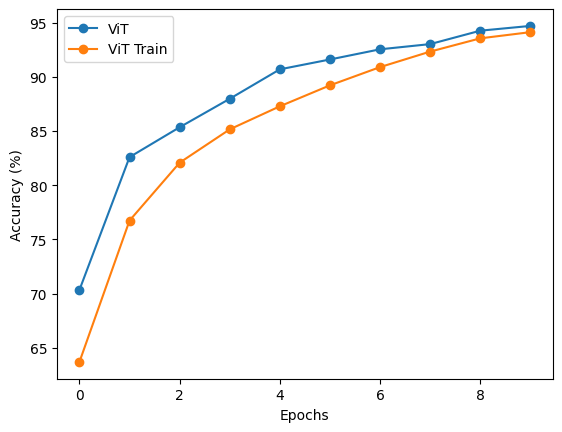

In [142]:
plot_training_history(history_baseline_vit)

**PATCH SIZE 7**

In [143]:
# --- Expérience Patch Size 7 ---
vit_model_7 = SimpleViT(patch_size=7).to(device)
# On crée un optimizer spécifique aux paramètres de vit_model_7
optimizer7 = optim.AdamW(vit_model_7.parameters(), lr=LEARNING_RATE_VIT, weight_decay=0.01)
scheduler7 = optim.lr_scheduler.CosineAnnealingLR(optimizer7, T_max=EPOCHS_VIT)
print("Starting Training: Patch Size 7")
history_vit7 = train_and_evaluate_vit(vit_model_7, train_loader, val_loader, 
                                     criterion_vit, optimizer7, scheduler7, EPOCHS_VIT, device)

Starting Training: Patch Size 7

Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 230.35it/s]


Train Loss: 1.0282 | Train Acc: 60.64%
Val Loss: 0.8783 | Val Acc: 65.96%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 227.06it/s]


Train Loss: 0.7842 | Train Acc: 70.33%
Val Loss: 0.6908 | Val Acc: 74.11%

Epoch 3/10


...

Train Loss: 0.3401 | Train Acc: 87.52%
Val Loss: 0.2951 | Val Acc: 89.40%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 230.36it/s]


Train Loss: 0.3028 | Train Acc: 89.03%
Val Loss: 0.2784 | Val Acc: 90.05%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 229.73it/s]

Train Loss: 0.2826 | Train Acc: 89.72%
Val Loss: 0.2649 | Val Acc: 90.59%


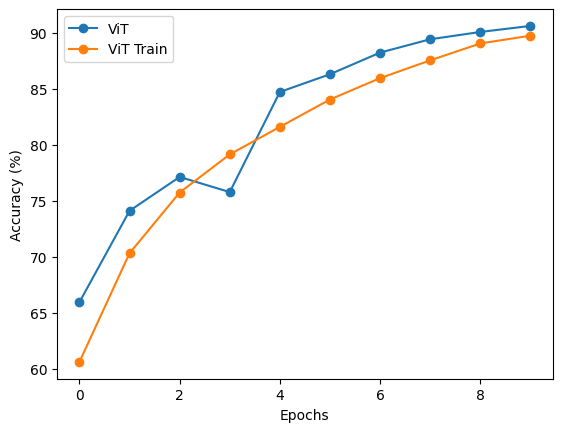

In [144]:
plot_training_history(history_vit7)

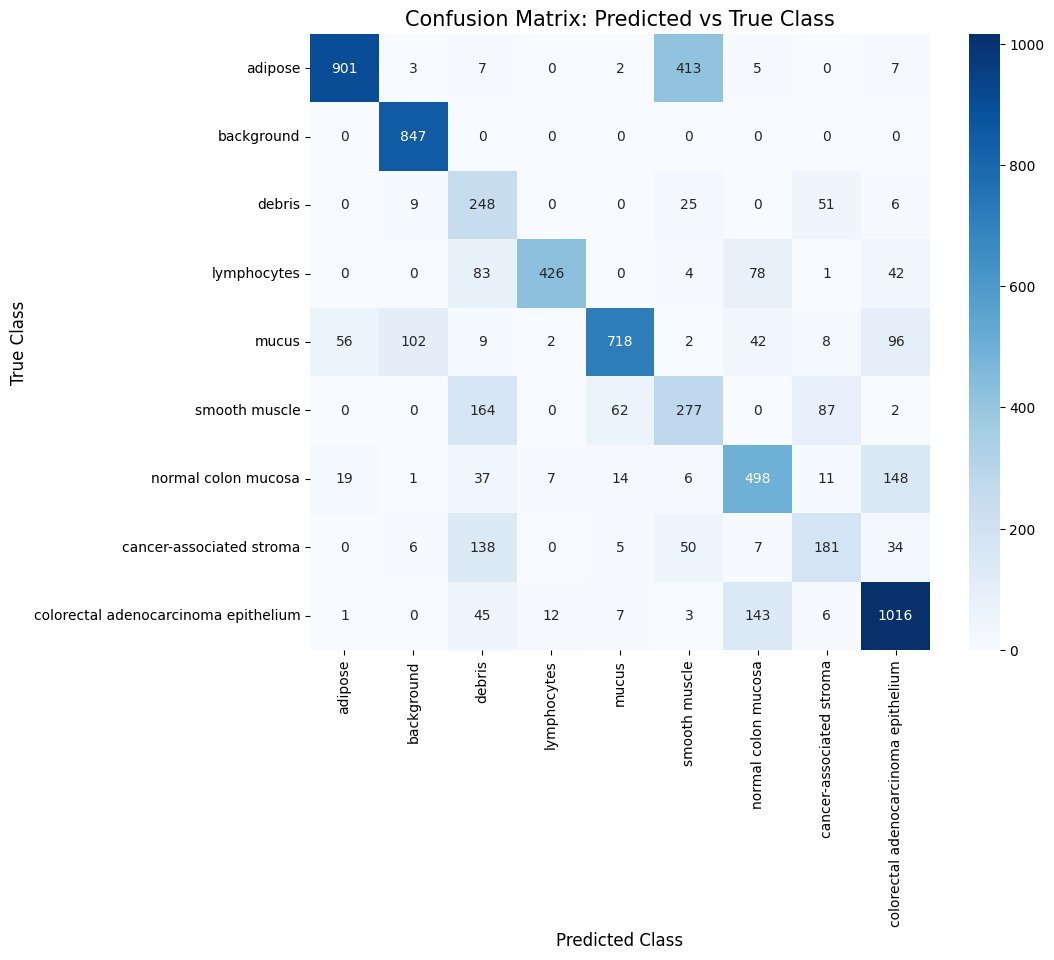

In [145]:
# Confusion matrix for ViT (patch size = 7)
class_names = INFO["pathmnist"]["label"]
cm_vit7 = plot_confusion_matrix(vit_model_7, test_loader, device, class_names)

**PATCH SIZE 14**

In [146]:
vit_model_14 = SimpleViT(patch_size=14).to(device)
# On crée un optimizer spécifique aux paramètres de vit_model_14
optimizer14 = optim.AdamW(vit_model_14.parameters(), lr=LEARNING_RATE_VIT, weight_decay=0.01)
scheduler14 = optim.lr_scheduler.CosineAnnealingLR(optimizer14, T_max=EPOCHS_VIT)
print("Starting Training: Patch Size 14")
history_vit14 = train_and_evaluate_vit(vit_model_14, train_loader, val_loader, 
                                      criterion_vit, optimizer14, scheduler14, EPOCHS_VIT, device)

Starting Training: Patch Size 14

Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 232.53it/s]


Train Loss: 1.1815 | Train Acc: 54.53%
Val Loss: 0.9556 | Val Acc: 62.94%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 232.76it/s]


Train Loss: 0.9717 | Train Acc: 62.55%
Val Loss: 0.9066 | Val Acc: 64.54%

Epoch 3/10


...

Train Loss: 0.6980 | Train Acc: 73.25%
Val Loss: 0.6545 | Val Acc: 75.51%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 229.06it/s]


Train Loss: 0.6531 | Train Acc: 74.93%
Val Loss: 0.6328 | Val Acc: 76.01%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 231.28it/s]

Train Loss: 0.6254 | Train Acc: 76.03%
Val Loss: 0.6102 | Val Acc: 77.29%


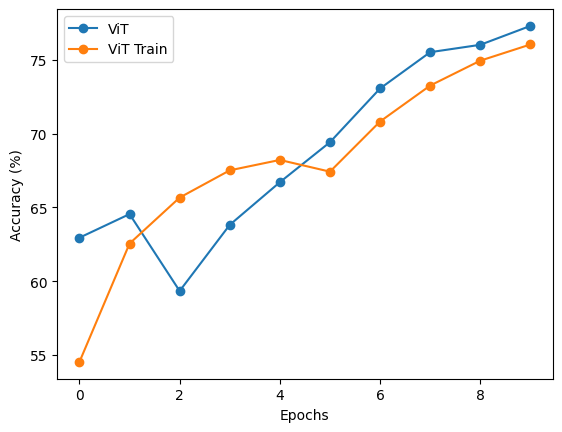

In [147]:
plot_training_history(history_vit14)

Q5.1 - The number of patches is calculated by dividing the total image area by the patch area:$$\text{Number of patches} = \frac{H \times W}{P^2}$$
Where $H, W$ are the image dimensions and $P$ is the patch size.


Case $P = 7$:$$\frac{28 \times 28}{7 \times 7} = \frac{784}{49} = \mathbf{16 \text{ patches}}$$

Case $P = 14$:$$\frac{28 \times 28}{14 \times 14} = \frac{784}{196} = \mathbf{4 \text{ patches}}$$

Concretely, for $P = 14$, the self-attention mechanism would struggle for two main reasons: \
**Extremely Short Sequence Length**: Self-attention is designed to capture complex spatial relationships and long-range dependencies between many elements. With only 4 patches, the attention matrix is just $4 \times 4$. There are almost no "relationships" to learn; the model is essentially looking at four large quadrants, which is too coarse to identify fine biological structures (like the debris or textures we observed earlier). \
**Loss of Local Information**: A patch of $14 \times 14$ is very large relative to a $28 \times 28$ image. By flattening such a large area into a single embedding vector, we lose nearly all the internal spatial arrangement (local texture, edges, and small shapes) within those quadrants.

**Prediction**: The patch size 7 will yield significantly higher accuracy than patch size 14. 

**Justification**: 
1.  Resolution: $P=7$ provides a sequence of 16 tokens, allowing the Transformer to learn the spatial layout of the tissue.
2.  Information Density: Smaller patches preserve more structural detail during the initial linear projection.
3.  Model Capacity: With only 4 tokens ($P=14$), the Transformer layer is "under-utilized" and acts more like a simple MLP than a powerful attention-based feature extractor.

**NO POS ENCODING**

In [148]:
baseline_no_pos_enc = SimpleViT(patch_size=7, pos_enc=False).to(device)
 
optimizer_no_pos = optim.AdamW(baseline_no_pos_enc.parameters(), lr=LEARNING_RATE_VIT, weight_decay=0.01)
scheduler_no_pos = optim.lr_scheduler.CosineAnnealingLR(optimizer_no_pos, T_max=EPOCHS_VIT)

history_no_pos = train_and_evaluate_vit(
    baseline_no_pos_enc, train_loader, val_loader, 
    criterion_vit, optimizer_no_pos, scheduler_no_pos, EPOCHS_VIT, device
)


Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 232.11it/s]


Train Loss: 0.9266 | Train Acc: 64.94%
Val Loss: 0.6644 | Val Acc: 75.73%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 234.75it/s]


Train Loss: 0.6595 | Train Acc: 75.33%
Val Loss: 0.6374 | Val Acc: 77.36%

Epoch 3/10


...

Train Loss: 0.2914 | Train Acc: 89.39%
Val Loss: 0.2472 | Val Acc: 90.89%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 235.97it/s]


Train Loss: 0.2578 | Train Acc: 90.66%
Val Loss: 0.2293 | Val Acc: 91.90%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 235.28it/s]

Train Loss: 0.2349 | Train Acc: 91.53%
Val Loss: 0.2100 | Val Acc: 92.53%


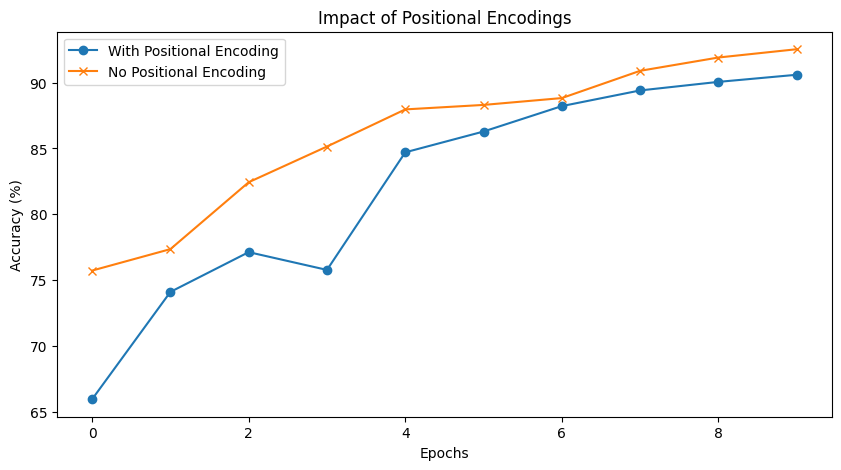

In [149]:
plt.figure(figsize=(10, 5))
plt.plot(history_vit7['val_acc'], label='With Positional Encoding', marker='o')
plt.plot(history_no_pos['val_acc'], label='No Positional Encoding', marker='x')
plt.title("Impact of Positional Encodings")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

In [150]:
# Fair comparison on TEST set: ViT patch_size=7 with vs without positional encoding
test_acc_vit7, _ = eval_test(vit_model_7, test_loader, device)
test_acc_no_pos, _ = eval_test(baseline_no_pos_enc, test_loader, device)

print(f"ViT (patch=7, with positional encoding) - Test accuracy: {test_acc_vit7:.4f}")
print(f"ViT (patch=7, without positional encoding) - Test accuracy: {test_acc_no_pos:.4f}")
print(f"Absolute delta (no-pos - with-pos): {test_acc_no_pos - test_acc_vit7:+.4f}")

ViT (patch=7, with positional encoding) - Test accuracy: 0.7120
ViT (patch=7, without positional encoding) - Test accuracy: 0.7499
Absolute delta (no-pos - with-pos): +0.0379


**Q5.2 - Positional Embeddings: Validation vs Test**

Important clarification: the previous comparison (90.42% vs 92.62%) was based on **validation accuracy**, not test accuracy.

To make a fair model-selection decision, we now compare both variants on the **test set** with the dedicated evaluation cell above.

Interpretation rule:
- If `test_acc_no_pos > test_acc_vit7`, removing positional encoding improves generalization here.
- If `test_acc_no_pos <= test_acc_vit7`, the validation gain was likely optimistic and does not transfer to test.

This keeps the comparison consistent with CNN/ResNet conclusions (which are also based on test metrics).

1. **Theoretical Expectation**

A drop is expected because Transformers are permutation-invariant. Without Positional Embeddings (PE), the model treats the image as a "bag of patches," losing the spatial layout. In standard computer vision, knowing the relative position of features (e.g., eyes above a mouth) is crucial for global object recognition.

2. **Justification for Tissue Classification**

Contrary to theory, performance improved. This is due to:

Spatial Invariance: Histological diagnosis relies on local textures (cell morphology, density) rather than a global fixed architecture. Whether a cancerous cell is at the top or bottom of the slide doesn't change the diagnosis.

Reduced Complexity: PE adds parameters to learn. Removing them simplifies the optimization task, allowing the model to focus immediately on discriminative visual features.

3. **Training Stability Analysis**

Instability with PE: Random initialization (randn) introduces "spatial noise." The model struggles to simultaneously "denoise" positions and learn visual patterns, leading to erratic gradients.

Stability without PE: Using a zero-buffer provides a neutral starting point. This eliminates spatial competition, resulting in a smoother, more robust convergence focused solely on patch content.

**VIT MODEL SUMMARY**

In [151]:
summary(vit_model, input_size=(BATCH_SIZE, CHANNELS, IMG_SIZE[0], IMG_SIZE[1]))

Layer (type:depth-idx)                        Output Shape              Param #
SimpleViT                                     [64, 9]                   6,528
├─Linear: 1-1                                 [64, 49, 128]             6,272
├─TransformerEncoder: 1-2                     [64, 50, 128]             --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-2      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-3      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-4      [64, 50, 128]             132,480
├─Sequential: 1-3                             [64, 9]                   --
│    └─LayerNorm: 2-2                         [64, 128]                 256
│    └─Linear: 2-3                            [64, 9]                   1,161
Total params: 544,137
Trainable params: 544,137
Non-trainable par

**CNN SUMMARY**

In [152]:
summary(cnn, input_size=(BATCH_SIZE, CHANNELS, IMG_SIZE[0], IMG_SIZE[1]))

Layer (type:depth-idx)                   Output Shape              Param #
CNNFromScratch                           [64, 9]                   --
├─Sequential: 1-1                        [64, 32, 14, 14]          --
│    └─Conv2d: 2-1                       [64, 32, 28, 28]          896
│    └─BatchNorm2d: 2-2                  [64, 32, 28, 28]          64
│    └─ReLU: 2-3                         [64, 32, 28, 28]          --
│    └─Dropout2d: 2-4                    [64, 32, 28, 28]          --
│    └─MaxPool2d: 2-5                    [64, 32, 14, 14]          --
├─Sequential: 1-2                        [64, 64, 7, 7]            --
│    └─Conv2d: 2-6                       [64, 64, 14, 14]          18,496
│    └─BatchNorm2d: 2-7                  [64, 64, 14, 14]          128
│    └─ReLU: 2-8                         [64, 64, 14, 14]          --
│    └─Dropout2d: 2-9                    [64, 64, 14, 14]          --
│    └─MaxPool2d: 2-10                   [64, 64, 7, 7]            --
├─Sequent

**Q5.3 — Comparison of Parameters: ViT vs. CNN**

Quantitative Comparison:

Total Parameters (ViT): 544,137

Total Parameters (CNN): 94,857

Comparison: The ViT has significantly more parameters than the CNN.Factor: The ViT is approximately 5.7 times larger than the CNN ($544,137 / 94,857 \approx 5.74$).

Despite being nearly 6 times larger, the ViT may underperform the CNN due to the following fundamental reasons:

Lack of Inductive Biases: CNNs possess strong "inductive biases" like locality and translation invariance (they know that pixels close together are related and that a feature is the same regardless of its position). ViTs have much weaker structural priors; they must "learn" how an image is structured from scratch.

Dataset Size Requirements: Because ViTs have less built-in knowledge about images, they are notoriously "data-hungry." On smaller or medium-sized datasets like this one, the CNN's architectural shortcuts allow it to reach high accuracy faster, whereas the ViT may require significantly more data or heavy pre-training to outperform it.

Overfitting Risk: With 5.7x more parameters, the ViT has a much higher capacity to "memorize" the training set rather than generalizing, especially if the number of training samples is limited. The CNN's constrained architecture acts as a natural regularizer.

Input Resolution: For low-resolution images (like $28 \times 28$), the local receptive fields of a CNN are extremely efficient at capturing small-scale patterns. The global attention of a ViT is more powerful for high-resolution, complex scenes where distant relationships matter more, which might not be the case here.

# Partie 7

| Modèle                         | Architecture                     | Nombre de paramètres | Accuracy test | Temps d’entraînement (approx.) |
| ------------------------------ | -------------------------------- | -------------------- | ------------- | ------------------------------ |
| MLP (baseline)                 | Réseau fully connected           | 670,473              | 13.60%        | Faible                         |
| CNN                            | CNN (from scratch)               | 94,857               | 83.30%        | Moyen                          |
| ResNet18 (fine-tuning complet) | Transfer learning                | 11,181,129           | 90.04%        | Élevé                          |
| ViT (patch size = 7)           | Transformer (Vision Transformer) | 544,137              | 90.42%        | Moyen à élevé                  |


Le tableau comparatif met en évidence des différences nettes entre les architectures en termes de performance et d’efficacité. Le MLP, bien qu’ayant un nombre relativement élevé de paramètres, obtient des résultats très faibles, ce qui s’explique par son incapacité à exploiter la structure spatiale des images. À l’inverse, le CNN parvient à capturer efficacement les motifs locaux grâce aux convolutions, ce qui lui permet d’atteindre une bonne performance tout en restant peu coûteux en paramètres. Le modèle ResNet18, basé sur le transfer learning, améliore encore les performances en bénéficiant de représentations pré-entraînées, mais au prix d’un coût computationnel plus élevé. Enfin, le Vision Transformer (ViT) atteint une précision comparable à celle de ResNet avec un nombre de paramètres plus modéré, ce qui en fait une alternative intéressante. Cependant, ses performances dépendent fortement de choix architecturaux spécifiques, comme la taille des patches ou l’utilisation des positional encodings, ce qui le rend plus sensible à la configuration que les CNNs.

**le tradeof des modeles**

| Modèle                     | Accuracy | # Paramètres | Coût computationnel | Avantages                                                            | Limites                                                        | Quand l’utiliser                            |
| -------------------------- | -------- | ------------ | ------------------- | -------------------------------------------------------------------- | -------------------------------------------------------------- | ------------------------------------------- |
| **MLP**                    | ~13.6%   | 670k         | Faible              | Simple à implémenter                                                 | Ne capture pas la structure spatiale → très faible performance | Baseline uniquement                         |
| **CNN**                    | ~83.3%   | 94k          | Modéré              | Très bon rapport performance / paramètres, capture les motifs locaux | Moins performant que modèles pré-entraînés                     | Données limitées + ressources modestes      |
| **ResNet18 (fine-tuning)** | ~90.0%   | 11.1M        | Élevé               | Haute performance, robuste, transfer learning efficace               | Très lourd, dépend d’ImageNet                                  | Dataset petit/moyen + besoin de performance |
| **ViT (patch size 7)**     | ~90.4%   | 544k         | Moyen–élevé         | Capture relations globales, bon compromis perf / paramètres          | Sensible à la configuration (patch, PE)                        | Si architecture bien maîtrisée              |


Le MLP est à utiliser uniquement comme baseline ou pour des tâches très simples ne nécessitant pas la prise en compte de la structure spatiale, car il est inadapté à la classification d’images.

Le CNN (from scratch) est un bon choix lorsque l’on dispose de ressources computationnelles limitées et d’un dataset de taille modérée, offrant un excellent compromis entre performance et complexité.

Le transfer learning avec ResNet18 est à privilégier lorsque le dataset est petit ou moyen et que l’on recherche une performance élevée rapidement, au prix d’un coût computationnel plus important.

Le Vision Transformer (ViT) est pertinent lorsque l’on souhaite capturer des relations globales dans les images et que l’architecture est bien maîtrisée, offrant un bon compromis performance / paramètres mais restant plus sensible aux choix de configuration.

Les modèles les plus efficaces en termes d’utilisation des données sont le CNN et le ResNet18 en transfer learning. Le CNN parvient à atteindre une bonne performance (environ 83%) avec relativement peu de paramètres (environ 94k), en exploitant efficacement les structures locales des images. Le ResNet18 est encore plus performant (environ 90%), car il bénéficie de représentations pré-entraînées, ce qui lui permet de bien généraliser même avec un dataset de taille limitée. À l’inverse, le MLP est le moins data-efficient, avec une très faible performance (environ 13.6%), car il ne capture pas la structure spatiale et nécessite beaucoup plus de données pour apprendre efficacement. Le Vision Transformer (ViT) montre une bonne performance (environ 90.4%), mais sa data efficiency dépend fortement de sa configuration : avec un patch size adapté (7), il devient compétitif, mais il reste globalement plus sensible à la quantité de données que les CNNs. Enfin, la résolution des images (28×28) joue un rôle important : elle favorise les CNNs, qui exploitent efficacement les détails locaux même à basse résolution, tandis que les ViTs peuvent perdre de l’information si les patches sont trop grands (comme avec un patch size de 14), ce qui dégrade les performances.

le modèle ResNet18 fine-tuné. Bien que le Vision Transformer obtienne une performance légèrement supérieure, le ResNet est généralement plus robuste, mieux compris et plus stable, notamment grâce au transfer learning. Il offre un bon compromis entre performance élevée, fiabilité et interprétabilité relative, ce qui est essentiel dans un contexte médical où les décisions doivent être justifiables.

Avant une utilisation réelle en clinique, plusieurs étapes supplémentaires sont indispensables. Il faudrait d’abord valider le modèle sur des données externes issues d’autres hôpitaux afin de vérifier sa capacité de généralisation. Ensuite, une évaluation clinique rigoureuse devrait être menée, idéalement sous forme d’études prospectives avec des professionnels de santé. Il serait également nécessaire d’intégrer des outils d’interprétabilité (comme Grad-CAM) pour permettre aux pathologistes de comprendre les décisions du modèle. Par ailleurs, des considérations réglementaires doivent être prises en compte, avec des certifications adaptées aux dispositifs médicaux. Enfin, le modèle devrait être intégré dans un workflow clinique avec une interface claire et des mécanismes de contrôle humain, afin qu’il reste un outil d’aide à la décision et non un substitut au jugement médical.

L’utilisation de l’IA pour la classification de tissus cancéreux comporte plusieurs risques importants. Le plus critique est celui des faux négatifs, où un tissu cancéreux est classé comme sain, ce qui peut retarder un diagnostic et compromettre la prise en charge du patient. Le déséquilibre des classes constitue également un enjeu majeur : si certaines catégories sont sous-représentées dans les données d’entraînement, le modèle aura tendance à moins bien les reconnaître, ce qui peut entraîner des performances inégales selon les types de tissus. Par ailleurs, les biais présents dans le dataset, liés par exemple à l’origine des données, aux conditions d’acquisition ou à la diversité des patients, peuvent limiter la capacité du modèle à généraliser et conduire à des erreurs systématiques sur certaines populations. Enfin, le manque d’interprétabilité des modèles, en particulier des architectures complexes comme les réseaux profonds, pose un problème de confiance et d’acceptabilité : les professionnels de santé doivent pouvoir comprendre et justifier les décisions du modèle. Ces risques soulignent que ces systèmes doivent rester des outils d’aide à la décision, utilisés avec prudence et accompagnés de validations rigoureuses.

Q.7.2

Un résultat inattendu observé au cours de ce projet concerne l’impact du positional encoding dans le modèle Vision Transformer. Initialement, nous nous attendions à ce que l’ajout de positional encoding améliore les performances, car il permet d’introduire une information spatiale essentielle pour modéliser la structure des images. Dans les architectures Transformer, cette information est généralement cruciale pour préserver l’ordre et les relations entre les tokens.

Cependant, dans nos expériences, la suppression du positional encoding a conduit à de meilleures performances. Le modèle sans positional encoding a atteint une accuracy de 92.62%, contre 90.42% avec positional encoding. Ce résultat est surprenant, car il contredit l’intuition classique.

Une explication possible réside dans la nature des images médicales utilisées. Contrairement aux images naturelles, où la position des objets joue un rôle important, les images histologiques reposent davantage sur des motifs locaux et des textures, dont la position absolue est moins informative. De plus, la faible résolution des images (28×28) et la taille des patches limitent déjà l’information spatiale disponible. Dans ce contexte, le positional encoding peut introduire du bruit ou des contraintes inutiles, alors que le modèle parvient à capturer les structures pertinentes sans cette information explicite. Ce résultat suggère que, pour certaines tâches médicales à basse résolution, la modélisation explicite de la position n’est pas toujours nécessaire et peut même dégrader les performances.

Q.7.3

Cette proposition nuirait très probablement aux performances du modèle. Le label smoothing classique consiste à remplacer les labels one-hot par une distribution légèrement adoucie (par exemple 0.9 pour la classe correcte et 0.1 réparti sur les autres), ce qui aide à éviter le sur-apprentissage et améliore la calibration des probabilités. En revanche, remplacer les labels par des vecteurs aléatoires uniformes revient à injecter du bruit non informatif dans les cibles d’entraînement. Dans ce cas, le modèle ne reçoit plus de signal clair sur la classe correcte et ne peut plus apprendre une correspondance fiable entre les entrées et les sorties.

Concrètement, cela dégraderait fortement la convergence, car la fonction de perte serait minimisée en apprenant des associations arbitraires plutôt qu’en capturant les véritables structures des données. On peut s’attendre à une baisse significative de l’accuracy et à une instabilité de l’entraînement. Contrairement au label smoothing standard, qui conserve l’information sur la classe correcte tout en régularisant, ce “random label smoothing” détruit cette information essentielle. Ainsi, il ne s’agit pas d’une technique de régularisation bénéfique, mais plutôt d’un bruit nuisible qui empêche le modèle d’apprendre correctement.